# Guided Lab 5.1: Building a Simple Neural Network Model

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 05: Introduction to Neural Networks**

## Lab Goal
Build and evaluate a simple neural network using TensorFlow/Keras and the `creditcard.csv` dataset.

Target:
- `Class = 0` → Normal transaction
- `Class = 1` → Fraudulent transaction


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 2: Load the Dataset

In [2]:
# Dataset lives in the central gitignored /datasets/ folder (exceeds GitHub's 100MB limit)
df = pd.read_csv("../../../datasets/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Explore the Dataset

In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset shape: (284807, 31)

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Step 4: Define Features and Target

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## Step 5: Split the Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)


## Step 6: Scale the Data

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (227845, 30)
Scaled testing shape: (56962, 30)


## Step 7: Build a Simple Neural Network

In [7]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

C:\Users\kayro\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Compile the Model

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Step 9: Train the Neural Network

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


   1/2849 ━━━━━━━━━━━━━━━━━━━━ 1:24:08 2s/step - accuracy: 0.0000e+00 - loss: 1.2209

  20/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0684 - loss: 1.0661        

  39/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1729 - loss: 0.9729

  61/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.2994 - loss: 0.8852

...

2773/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0022

2798/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0022

2825/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0022

2847/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0022

2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9994 - val_loss: 0.0033


## Step 10: Visualize Training Performance

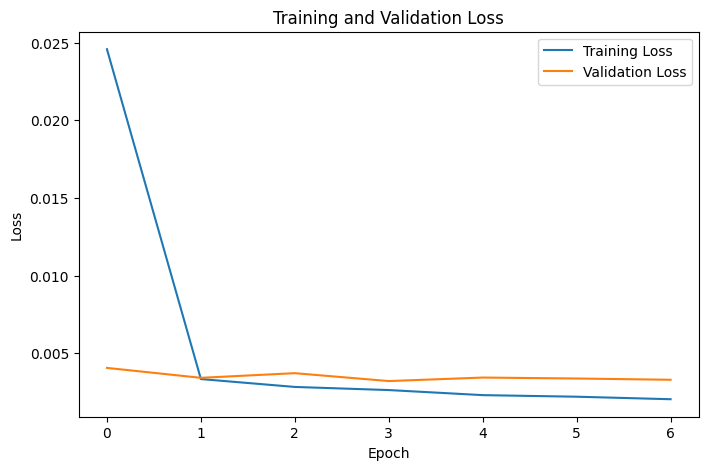

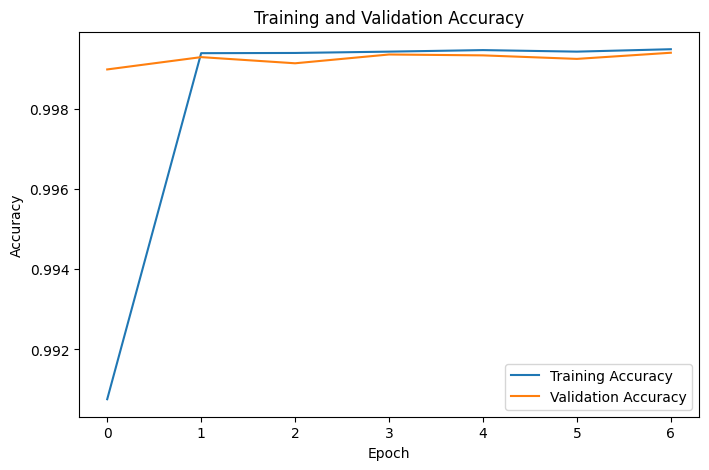

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Step 11: Generate Predictions

In [11]:
y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.5).astype(int).flatten()

print("First 10 predicted probabilities:")
print(y_prob[:10].flatten())

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

   1/1781 ━━━━━━━━━━━━━━━━━━━━ 2:18 78ms/step

  41/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step   

  76/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 112/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 156/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

...

1692/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

1738/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


First 10 predicted probabilities:
[2.5055793e-05 1.1220281e-05 1.5712129e-05 2.8795841e-05 8.0780229e-03
 1.0164074e-05 2.5097023e-07 4.1490966e-05 4.1040659e-04 5.5239783e-05]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]


## Step 12: Evaluate the Neural Network

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9993153330290369
Precision: 0.780952380952381
Recall: 0.8367346938775511
F1 Score: 0.8078817733990148

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.84      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## Step 13: Confusion Matrix

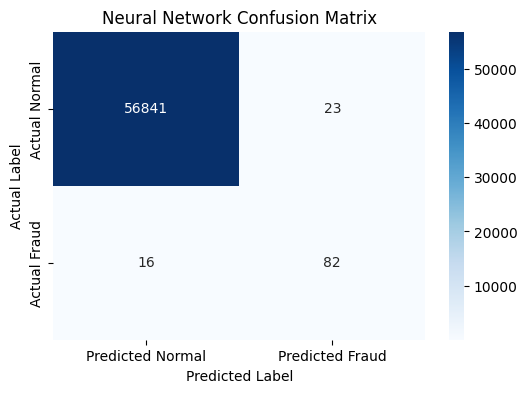

[[56841    23]
 [   16    82]]


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(cm)

## Step 14: Adjust the Prediction Threshold

In [14]:
threshold = 0.3
y_pred_adjusted = (y_prob > threshold).astype(int).flatten()

print("Evaluation with threshold =", threshold)
print(classification_report(y_test, y_pred_adjusted, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

Evaluation with threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.84      0.75        98

    accuracy                           1.00     56962
   macro avg       0.84      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56825    39]
 [   16    82]]


## Step 15: Example Interpretation

This neural network was trained to classify transactions as normal or fraudulent. Because the dataset is highly imbalanced, accuracy alone may be misleading. Precision, recall, and F1 score provide more meaningful information.

- High precision means fewer normal transactions are incorrectly flagged as fraud.
- High recall means more actual fraud cases are detected.
- False negatives are risky because fraud may be missed.
- False positives can create unnecessary alerts.

Changing the threshold can change the balance between precision and recall.


## Reflection Questions

**1. What was the model accuracy?**
The neural network reached an overall accuracy of about **99.93%** (0.9993) on the test set.

**2. Why might accuracy alone be misleading for this dataset?**
The data is extremely imbalanced — only **0.17%** of transactions are fraud (492 of 284,807). A model that simply predicted "normal" for everything would still score about 99.8% accuracy while catching **zero** fraud. High accuracy therefore says almost nothing about how well the rare fraud class is detected.

**3. What do precision and recall tell us about fraud detection?**
For the fraud class, precision was **0.78** and recall was **0.84**. Precision means that of all transactions flagged as fraud, about 78% really were fraud (the rest were false alarms). Recall means that of all actual fraud, about 84% was caught. In fraud detection recall is usually the priority (missed fraud is costly), but precision must stay high enough to avoid overwhelming analysts with false alerts.

**4. What does the confusion matrix show?**
At the default 0.5 threshold the matrix was `[[56841, 23], [16, 82]]`: 56,841 normal transactions correctly cleared, 23 normal transactions wrongly flagged as fraud (false positives), 16 frauds missed (false negatives), and **82 of 98 frauds correctly caught** (true positives).

**5. Did changing the prediction threshold affect model performance?**
Yes. Lowering the threshold to 0.3 kept recall the same (still 82 of 98 frauds caught) but increased false positives from 23 to 39, which dropped fraud-class precision from 0.78 to **0.68** and F1 from 0.81 to **0.75**. In this run a lower threshold hurt precision without recovering any of the missed fraud, so 0.5 was the better operating point.

**6. How can neural networks support cybersecurity and fraud detection?**
They learn complex, non-linear relationships across many features, scale to very large transaction volumes, and can automate detection of anomalies, intrusions, malware, and fraud in near real time, adapting as new labeled examples arrive.

**7. What are some limitations of neural networks in cybersecurity applications?**
They need large amounts of labeled data, struggle with severe class imbalance, behave as opaque "black boxes" that are hard to explain to auditors, can be fooled by adversarial inputs, are comparatively expensive to train, and require retraining as attack and fraud patterns evolve over time.


## Submission Checklist

- All code cells run without errors
- Dataset path is correct
- Neural network model is trained
- Training plots are displayed
- Evaluation metrics are displayed
- Confusion matrix is included
- Reflection questions are answered
- Completed `.ipynb` file is submitted in Canvas
